<a href="https://colab.research.google.com/github/sgulyano/CMKL41-685/blob/main/41_685lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMKL41-685 Computer Vision Lab 5

CMKL University

By Sarun Gulyanon

### Goal

Introduce students to the use of Optical Flow for tracking objects (e.g., cars) in motion sequences or videos.


### Outline

In this lab, students will study how Optical Flow represents pixel movement between consecutive frames. The technique estimates motion based on changes in pixel brightness and expresses it as 2D motion vectors showing how each pixel shifts to its new position in the next frame.

Optical Flow relies on two key assumptions:
1. The brightness of a pixel corresponding to the same object remains constant between frames.
2. Neighboring pixels tend to have similar motion.

This lab will employ Gunnar Farneback's algorithm [2, 3] to compute Dense Optical Flow, meaning every pixel in the image will have an associated motion vector indicating its displacement between frames. This contrasts with Sparse Optical Flow, which computes motion vectors only for selected pixels with distinct features.

### References
1. https://docs.opencv.org/4.x/d4/dee/tutorial_optical_flow.html
2. Farneback, G. “Two-Frame Motion Estimation Based on Polynomial Expansion.” In Proceedings of the 13th Scandinavian Conference on Image Analysis, 363 - 370. Halmstad, Sweden: SCIA, 2003.
3. https://www.mathworks.com/help/vision/ref/opticalflowfarneback.html

---

## 0. Download Dataset

Download the sample video of cars driving on the road from https://github.com/savnani5/Optical-Flow-Motion

In [1]:
!wget -O "cars_on_highway.mp4" https://drive.google.com/uc?id=1TEfEyGDJvn8NSa7xUS5THI9HIkpTINCa&export=download

--2025-10-27 00:37:04--  https://drive.google.com/uc?id=1TEfEyGDJvn8NSa7xUS5THI9HIkpTINCa
Resolving drive.google.com (drive.google.com)... 142.251.2.113, 142.251.2.100, 142.251.2.102, ...
Connecting to drive.google.com (drive.google.com)|142.251.2.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1TEfEyGDJvn8NSa7xUS5THI9HIkpTINCa [following]
--2025-10-27 00:37:04--  https://drive.usercontent.google.com/download?id=1TEfEyGDJvn8NSa7xUS5THI9HIkpTINCa
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2081120 (2.0M) [video/mp4]
Saving to: ‘cars_on_highway.mp4’

cars_on_highway.mp4 100%[===================>]   1.98M  7.50MB/s    in 0.3s    

2025-10-27 00:37:07 (7.50 MB/s) - ‘cars_on_

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

Open the video file with the `VideoCapture` function

In [3]:
cap = cv2.VideoCapture("cars_on_highway.mp4")
ret, frame1 = cap.read()
width = frame1.shape[1]
height = frame1.shape[0]

Create images to store the annotated motion positions of cars in each frame and record the Optical Flow for every frame.

In [4]:
mask = np.zeros_like(frame1)

hsv = np.zeros_like(frame1)
hsv[...,1] = 255

Open files to save the tracking results of car positions in the images and the Optical Flow computed for each frame.

In [5]:
out = cv2.VideoWriter('cars_track.mp4', cv2.VideoWriter_fourcc(*'MP4V'), 20, (width,height))
out_opf = cv2.VideoWriter('cars_flow.mp4', cv2.VideoWriter_fourcc(*'MP4V'), 20, (width,height))

Implement a function to overlay the Optical Flow visualization onto the images.

In [6]:
def draw_flow(img, flow, step=25):
    h, w = img.shape[:2]
    y, x = np.mgrid[step/2:h:step, step/2:w:step].reshape(2,-1).astype(int)
    fx, fy = flow[y,x].T
    lines = np.vstack([x, y, x+fx, y+fy]).T.reshape(-1, 2, 2)
    lines = np.int32(lines + 0.5)
    vis = img
    cv2.polylines(vis, lines, 0, (0, 255, 0), 2)
    for (x1, y1), (x2, y2) in lines:
        cv2.circle(vis, (x1, y1), 2, (0, 0, 255), -1)
    return vis

Input the position of the object or car to be tracked in the initial frame, and define the color for annotation.

In [7]:
prvs = cv2.cvtColor(frame1,cv2.COLOR_BGR2GRAY)

p0 = np.array([[[930,700]],
               [[760,500]],
               [[700,380]],
               [[590,340]],
               [[1020,380]],
               [[1360,560]],
               [[330,320]]], dtype='float32')
color = np.random.randint(0, 255, (7, 3))

## 2. Optical Flow Calculation and Object Tracking

For each subsequent frame, perform the following steps:
1. Compute the Optical Flow for the current frame.
2. Determine the new position of the object in the next frame.
3. Save the results and update the frame and object position.

In [8]:
while(1):
    ret, frame2 = cap.read()

    if ret == True:
        width = frame1.shape[1]
        height = frame1.shape[0]

        # calculate optical flow
        next = cv2.cvtColor(frame2,cv2.COLOR_BGR2GRAY)
        flow = cv2.calcOpticalFlowFarneback(prvs,next, None, 0.5, 3, 15, 3, 5, 1.2, 0)

        # calculate new objects' positions
        p1 = p0 + flow[np.int16(np.round(p0[:,:,1])), np.int16(np.round(p0[:,:,0])),:]
        p1[:,:,0] = np.clip(p1[:,:,0], 0, width-1)
        p1[:,:,1] = np.clip(p1[:,:,1], 0, height-1)

        # draw the tracks
        img = frame2
        for i, (new, old) in enumerate(zip(p1, p0)):
            a, b = new.ravel()
            c, d = old.ravel()
            mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 5)
            img = cv2.circle(img, (int(a), int(b)), 10, color[i].tolist(), -1)
        img = cv2.add(img, mask)

        # draw the optical flow
        mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
        hsv[...,0] = ang*180/np.pi/2
        hsv[...,2] = cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX)
        bgr = cv2.cvtColor(hsv,cv2.COLOR_HSV2BGR)
        frame3 = draw_flow(frame2, flow)

        # save to vdo file
        out.write(img)
        out_opf.write(frame3)

        # update frame and objects' positions
        prvs = next
        p0 = p1
    else:
        break
cap.release()
out.release()
out_opf.release()
print('done')

done


Display the tracking result image of the cars; each line represents the motion of a single object.

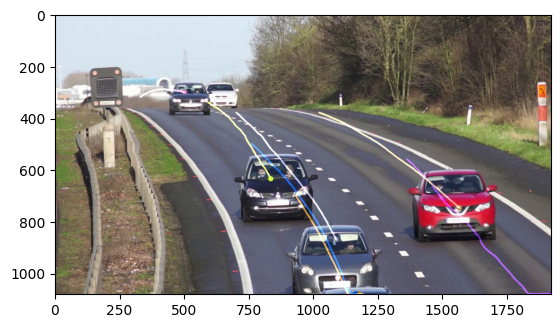

In [9]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)/255)

## 3. Results

To make it viewable on Colab, compress the video with `ffmpeg` and display it using HTML.

In [10]:
from IPython.display import HTML
from base64 import b64encode

In [11]:
!ffmpeg -y -i cars_track.mp4  -vcodec libx264  cars_track_compress.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [12]:
mp4 = open('cars_track_compress.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=600 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

In [13]:
!ffmpeg -y -i cars_flow.mp4  -vcodec libx264  cars_flow_compress.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [14]:
mp4 = open('cars_flow_compress.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=1000 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

----